## Initial testing
just getting some plots and basic analysis for the initial data we have

In [1]:
import numpy as np
from scipy.optimize import curve_fit
import pandas as pd
import matplotlib.pyplot as plt
from uncertainties import ufloat, unumpy

import Methods as m
import importlib
importlib.reload(m)

<module 'Methods' from '/Users/markzhitnitsky/Desktop/School/2025-26 Year/PHYS409/Experiment 2 - Optical Pumping/Code/Methods.py'>

In [64]:
# def multi_lorentz(x, A, h1, g1, x0_1, h2, g2, x0_2, h3, g3, x0_3):
#     dip1 = h1 * (g1**2) / ((x - x0_1)**2 + g1**2)
#     dip2 = h2 * (g2**2) / ((x - x0_2)**2 + g2**2)
#     dip3 = h3 * (g3**2) / ((x - x0_3)**2 + g3**2)

#     return A - (dip1 + dip2 + dip3)

In [2]:
freq = 25
savename = "5s measurement Mar 9 - " + str(freq) + 'kHz'
time, y1, y2, y2_norm = m.read_transmission_csv('./data/Mar 9 measurement/NewFile' + str(freq) + 'kHz' + '.csv')


# # Load the file, skipping the first two header rows
# df = pd.read_csv('./data/Mar 6 measurement/50sec_measurement.csv', skiprows=2, usecols=[0, 1, 2], names=['Sequence', 'CH1', 'CH2'])
# dfTimevals = pd.read_csv('./data/Mar 6 measurement/50sec_measurement.csv', skiprows=1, usecols=[3,4], names=['Start','Increment'])
#
# # Access the columns as arrays for your fitting function
# x = df['Sequence'].values
# y1 = df['CH1'].values
# y2 = df['CH2'].values
#
# timeStep = dfTimevals["Increment"].values[0]
#
# time = x * timeStep
# y2_norm = y2 - min(y2)
# y2_norm = y2_norm / max(y2_norm)

# filepath = './data/Mar 6 measurement/50sec_measurement.csv'
# df = pd.read_csv(filepath, skiprows=2, usecols=[0, 1, 2],
#                         names=['Sequence', 'CH1', 'CH2'])
# dfTimevals = pd.read_csv(filepath, skiprows=1, usecols=[3, 4],
#                          names=['Start', 'Increment'])
#
# # Access the columns as arrays for your fitting function
# x = df['Sequence'].values
# y1 = df['CH1'].values
# y2 = df['CH2'].values
#
# timeStep = dfTimevals["Increment"].values[0]
#
# time = x * timeStep
# y2_norm = y2 - min(y2)
# y2_norm = y2_norm / max(y2_norm)


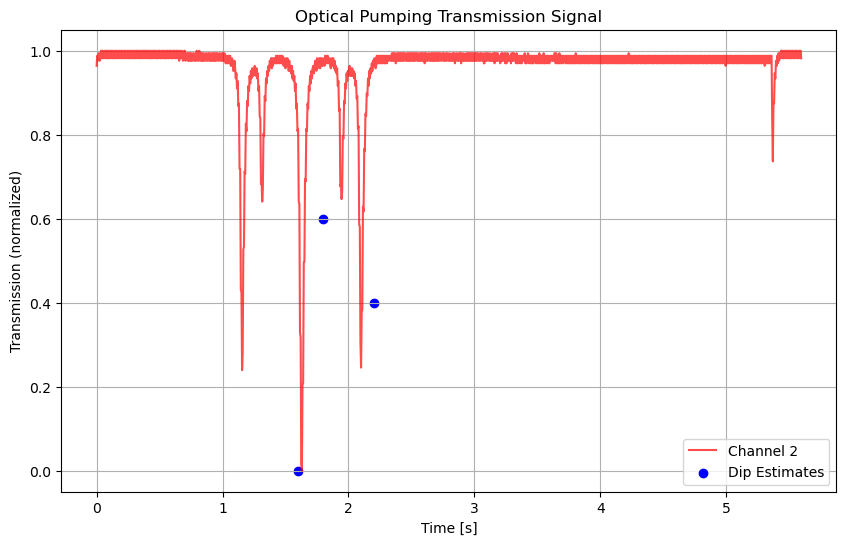

In [3]:
t0 = 0.4
nCut = (t0 // (time[1] - time[0])).astype(int)

time_cutFirst = time[nCut:] - t0
y2_norm_cutFirst = y2_norm[nCut:]

x0s = np.array([1.6,1.8,2.2])
# x0_1 = 19
# x0_2 = 31.5
# x0_3 = 38

# print(nCut)


m.plot_normalized_transmission(time_cutFirst, y2_norm_cutFirst, x0s, savename)

# plt.figure(figsize=(10, 6))
# # Plot CH1 and CH2
# plt.plot(time, y1, label='Channel 1', color='blue', alpha=0.7)
# plt.plot(time, y2_norm, label='Channel 2', color='red', alpha=0.7)
# # plt.scatter([x0_1,x0_2,x0_3], [0,0.6,0.4], label='Dip Estimates', color='blue')
# # plt.plot(time,y2_norm, label='Channel 2 normalized', color='red', alpha=0.7)
#
# # Labels and formatting
# plt.xlabel('Time [s]')
# plt.ylabel('Transmission (normalized)')
# plt.title('Optical Pumping Transmission Signal')
# plt.legend()
# plt.grid(True)
# plt.savefig("/figures/]" + savename, dpi=300)
#
# plt.show()

In [4]:
#    (A, h1, g1, x0_1, h2, g2, x0_2,  h3, g3, x0_3):
variables = ["A", "h1", "g1", "x0_1", "h2", "g2", "x0_2",  "h3", "g3", "x0_3"]
p0 = (1, 1, 0.3, x0s[0], 0.3, 0.1, x0s[1], 0.5, 0.1, x0s[2])
lower_bound = (0,0,0,0,0,0,0,0,0,0)
upper_bound = (2,2,2,100,2,2,100,2,2,100)
bounds = [lower_bound, upper_bound]
popt, pcov = curve_fit(m.triple_lorentz, time_cutFirst, y2_norm_cutFirst, p0=p0, bounds=bounds)
perr = np.sqrt(np.diag(pcov))
# popt, pcov = curve_fit(multi_lorentz, x, y2)
# print(popt)
for val, name in zip(popt,variables):
    print(name, val)

A 0.9751677706572638
h1 0.9648040041808671
g1 0.016589565185300456
x0_1 1.6297067061722823
h2 0.3407520610145041
g2 0.012250892797295606
x0_2 1.944400362982891
h3 0.7171016262607983
g3 0.014683155503463214
x0_3 2.1016500841655423


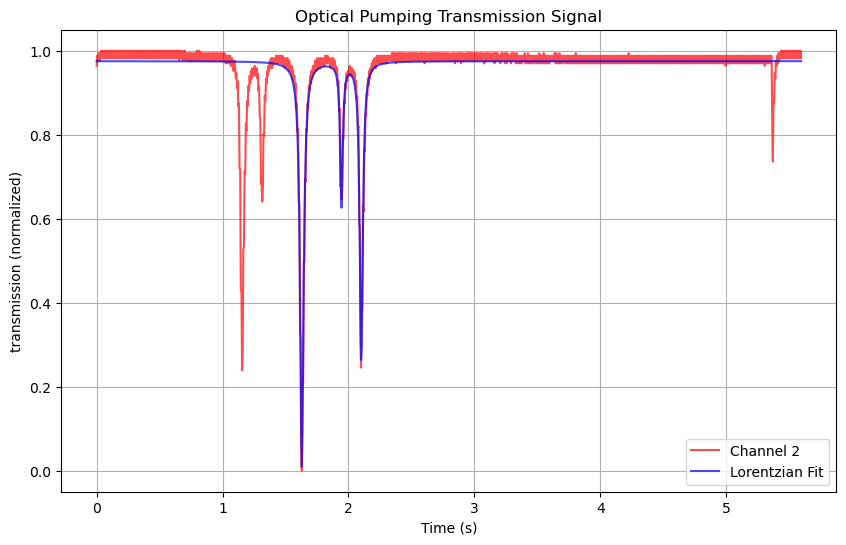

In [5]:
m.plot_fitted_transmission(time_cutFirst, y2_norm_cutFirst, popt, m.triple_lorentz, "fit to " + savename)
# plt.figure(figsize=(10, 6))
#
# # Plot CH1 and CH2
# # plt.plot(df['Sequence'], df['CH1'], label='Channel 1', color='blue', alpha=0.7)
# plt.plot(time_cutFirst, y2_norm_cutFirst, label='Channel 2', color='red', alpha=0.7)
# plt.plot(time, m.multi_lorentz(time,*popt), label='Lorentzian Fit', color='blue', alpha=0.7)
#
# # Labels and formatting
# plt.xlabel('Time (s)')
# plt.ylabel('transmission (normalized)')
# plt.title('Optical Pumping Transmission Signal')
# plt.legend()
# plt.grid(True)
#
# plt.show()

In [6]:
x0_1_u = ufloat(popt[3], perr[3]) + t0
x0_2_u = ufloat(popt[6], perr[6]) + t0
x0_3_u = ufloat(popt[9], perr[9]) + t0

# 3. Handle indexing (indices must be integers, so we use n)
dt = time[1] - time[0]
x0_1_index = int(x0_1_u.n // dt)
x0_2_index = int(x0_2_u.n // dt)
x0_3_index = int(x0_3_u.n // dt)

numAvg = 10

# 4. Calculate mean voltages (V) with uncertainty
# We treat the raw data y1 as having some inherent noise (e.g., std dev of the mean)
v_1 = ufloat(np.mean(y1[x0_1_index - numAvg : x0_1_index + numAvg]),
             np.std(y1[x0_1_index - numAvg : x0_1_index + numAvg]) / np.sqrt(2*numAvg))
v_2 = ufloat(np.mean(y1[x0_2_index - numAvg : x0_2_index + numAvg]),
             np.std(y1[x0_2_index - numAvg : x0_2_index + numAvg]) / np.sqrt(2*numAvg))
v_3 = ufloat(np.mean(y1[x0_3_index - numAvg : x0_3_index + numAvg]),
             np.std(y1[x0_3_index - numAvg : x0_3_index + numAvg]) / np.sqrt(2*numAvg))

# 5. Define calibration constant
# Note: if there is uncertainty in the 0.6 factor, you should make it a ufloat too
VtoB = ufloat(0.6 * 10**(-4) / 10,0.6 * 10**(-4) / 10/100) # this factor of 10 is only for measurements up to and including Mar 9

# 6. Calculate B fields (Uncertainties propagate automatically here)
Rb_85 = (v_2 - v_1) * VtoB
Rb_87 = (v_3 - v_1) * VtoB

print(f"v_1: {v_1/10:.3e} V")

print(f"Rb87: {Rb_87:.3e} T")
print(f"Rb85: {Rb_85:.3e} T")

v_1: (3.000+/-0.034)e-01 V
Rb87: (5.448+/-0.306)e-06 T
Rb85: (3.552+/-0.268)e-06 T


In [70]:
filepath = 'models/BFreqRatiosUncertain.csv'

m.append_to_v_ratio_csv(freq, Rb_87, Rb_85, filepath)